# Gaussian Process Regression for effective acoustic field mapping

### Imports

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import os
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator

from usnmexps.calib_utils import load_mapping_data
from usnmexps.pltutils import *
from usnmexps.utils import logger
from usnmexps.adaptive_mappers import GPRFieldMapper

figs = {}

loading paths from /Users/tlemaire/Documents/data/usnmexps_mock_data


## Load mapping data 

In [3]:
# Load 3D mapping data from file
mapping_fpath = '/Users/tlemaire/Desktop/TransducerGraphs/T6-08-22#1_glass2layers_2.030MHz_brutemap_NH0040_2023.01.27_θY15deg_DX2.0Y2.0Z6.0mm_nX21Y21Z49.csv'
coords_per_dim, Ptrue, fcode = load_mapping_data(mapping_fpath)

# Transform coordinates to mm
coords_per_dim = {k: v / 1e3 for k, v in coords_per_dim.items()}  # um -> mm

# Extract dimensions and input limits
nperdim = {k: v.size for k, v in coords_per_dim.items()}
bounds_per_dim = {k : np.array([v.min(), v.max()]) for k, v in coords_per_dim.items()}

 13/06/2025 15:55:55: loading mapping data from "T6-08-22#1_glass2layers_2.030MHz_brutemap_NH0040_2023.01.27_θY15deg_DX2.0Y2.0Z6.0mm_nX21Y21Z49.csv"
 13/06/2025 15:55:55: found 21609 points in mapping data
 13/06/2025 15:55:55: applying Sz transform
 13/06/2025 15:55:55: applying Ry(-15°) transform
 13/06/2025 15:55:55: applying T(1552.9142706151251, -1.1368683772161603e-13, 204.4450422655902) transform
 13/06/2025 15:55:55: identifying "true uniques" coordinates in each dimension from 21609 XYZ coordinates
 13/06/2025 15:55:55: reconstructed [21, 21, 49] grid dimensions
 13/06/2025 15:55:55: reconstructing [21, 21, 49] pressure field matrix


## Create evaluation function

 13/06/2025 15:55:55: creating sampling function...
 13/06/2025 15:55:55: generating mesh domain...
 13/06/2025 15:55:55: plotting focus slices across each dimension


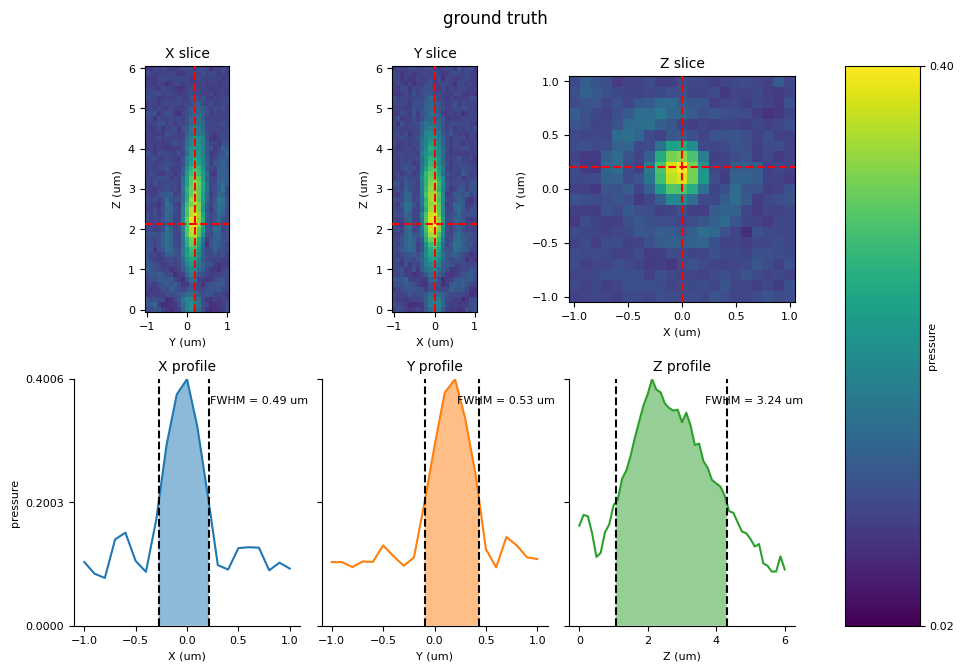

In [4]:
# Create field sampling function
logger.info('creating sampling function...')
feval = RegularGridInterpolator(
    tuple(coords_per_dim.values()), 
    Ptrue, 
    method='linear',
    bounds_error=False,
    fill_value=None,
)

# Plot sampling function predictions on denser grid
logger.info('generating mesh domain...')
nperdim_dense = {
    'X': 25,
    'Y': 25,
    'Z': 99
}
nperdim_dense = nperdim
coords_per_dim_dense = {k: np.linspace(*v, nperdim_dense[k]) for k, v in bounds_per_dim.items()}
bounds_per_dim_dense = {k : np.array([v.min(), v.max()]) for k, v in coords_per_dim_dense.items()}
Xdense = np.meshgrid(*coords_per_dim_dense.values(), indexing='ij')
Xdense_serialized = np.vstack([x.ravel() for x in Xdense]).T
Pdense_serialized = feval(Xdense_serialized)
Pdense = Pdense_serialized.reshape(*[v.size for v in coords_per_dim_dense.values()])

# Get normalizer and scalar mappable from original data
Pbounds = np.array([Pdense.min(), Pdense.max()])
norm = plt.Normalize(vmin=Pbounds[0], vmax=Pbounds[1])
sm = plt.cm.ScalarMappable(cmap='viridis', norm=norm)

# Plot field slices through focus
figs['ground truth field'] = plot_acoustic_field(
    coords_per_dim_dense,
    Pdense,
    'focus',
    mark_focus='center',
    bounds=Pbounds,
    zoffset=0.,
    title='ground truth'
);

## Map field using GPR model and evaluate its accuracy

 13/06/2025 15:55:56: GPRFieldMapper(X=[-1.  1.], Y=[-1.  1.], Z=[0. 6.], varscale=0.5, proj=XYZ): naive kernel = 0.447**2 * RBF(length_scale=[0.5, 0.5, 0.5]) + WhiteKernel(noise_level=0.05) + 0.447**2
 13/06/2025 15:55:56: GPRFieldMapper(X=[-1.  1.], Y=[-1.  1.], Z=[0. 6.], varscale=0.5, proj=XYZ): instantiating GPR model
 13/06/2025 15:55:56: GPRFieldMapper(X=[-1.  1.], Y=[-1.  1.], Z=[0. 6.], varscale=0.5, proj=XYZ): no initial number of samples provided -> aiming for 0.5*varscale (0.25) pitch
 13/06/2025 15:55:56: GPRFieldMapper(X=[-1.  1.], Y=[-1.  1.], Z=[0. 6.], varscale=0.5, proj=XYZ): generated initial population of 1536 random points
 13/06/2025 15:56:04: GPRFieldMapper(X=[-1.  1.], Y=[-1.  1.], Z=[0. 6.], varscale=0.5, proj=XYZ, ninit=1536, init_mode=None, niters=0): evaluated function at initial points
 13/06/2025 15:56:20: GPRFieldMapper(X=[-1.  1.], Y=[-1.  1.], Z=[0. 6.], varscale=0.5, proj=XYZ, ninit=1536, init_mode=None, niters=0): fitted GPR model: kernel = 0.022**2 *

100%|██████████| 3/3 [01:24<00:00, 30.86s/it]

 13/06/2025 15:58:21: GPRFieldMapper(X=[-1.  1.], Y=[-1.  1.], Z=[0. 6.], varscale=0.5, proj=XYZ, ninit=1536, init_mode=random, nperiter=500, niters=3): maximum number of iterations (3) reached


4it [02:01, 30.44s/it]                       

 13/06/2025 15:58:21: GPRFieldMapper(X=[-1.  1.], Y=[-1.  1.], Z=[0. 6.], varscale=0.5, proj=XYZ, ninit=1536, init_mode=random, nperiter=500, niters=3): fitted GPR model: kernel = 0.0221**2 * RBF(length_scale=[0.197, 0.197, 1.02]) + WhiteKernel(noise_level=9.54e-05) + 0.102**2


metric
C1 rel. change          0.000000
RBF_X rel. change       0.000000
RBF_Y rel. change       0.000000
RBF_Z rel. change       0.000000
W rel. change           0.000000
C0 rel. change          0.000000
LML change              0.000000
rel. max uncertainty    0.036837
r2                      0.808414
max. rel. error         5.217910
dtype: float64
 13/06/2025 15:58:28: plotting focus slices across each dimension
 13/06/2025 15:58:28: plotting focus slices across each dimension
 13/06/2025 15:58:28: Y profile: found 3 crossings on right side of peak


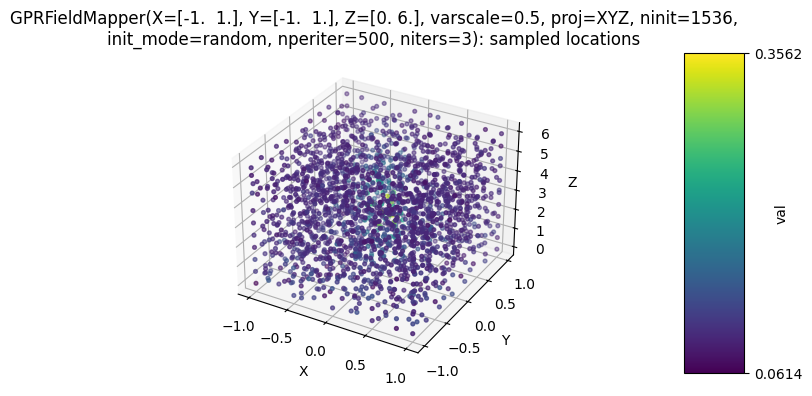

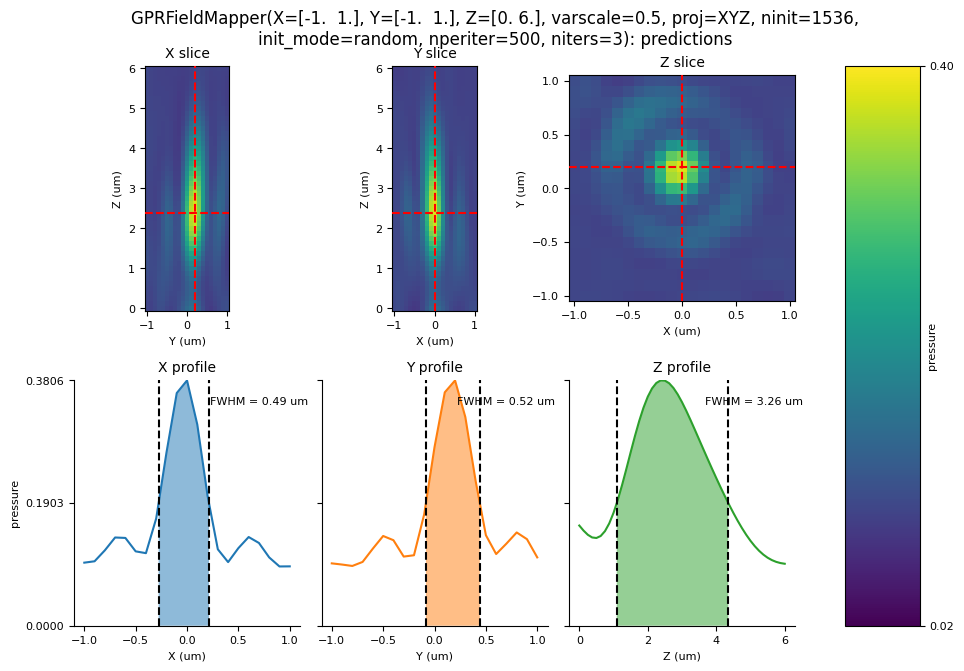

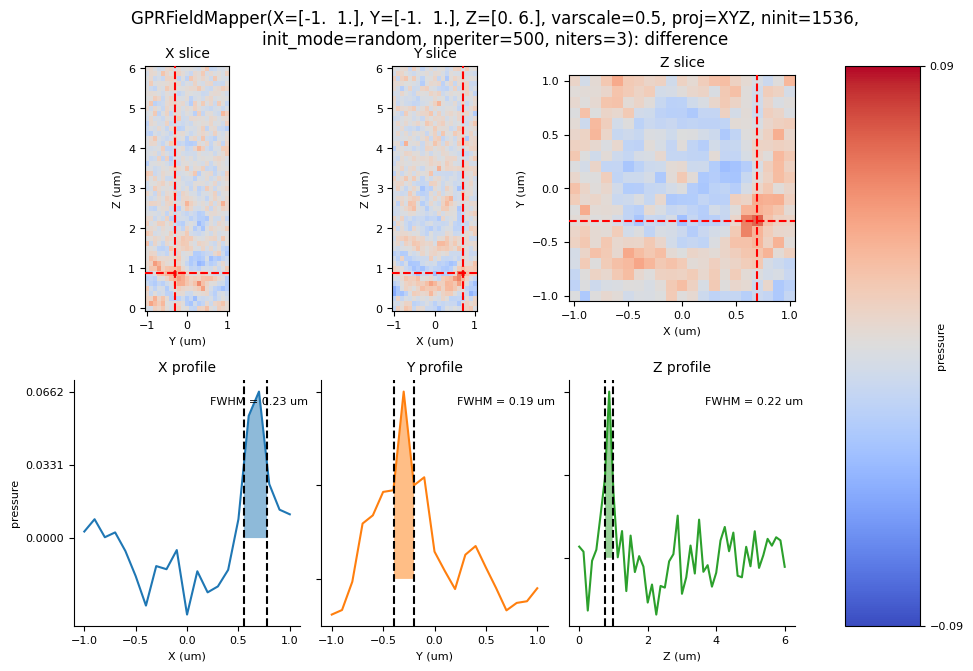

In [5]:
proj = 'XYZ'  # projection key
variation_scale = 0.5  # typical variation scale (in mm)
max_pts = 3000
nperit = 500

# Evaluate mapper prediction upon initialization
all_conv_metrics = []

# Create mapper object
mapper = GPRFieldMapper(
    feval,
    bounds_per_dim, 
    varscale=variation_scale,
    projkey=proj,
)

# Initialize mapper with a random sampling of the domain
mapper.initialize()

# Optimize iteratively until convergence or max_pts reached
mapper.optimize(Xdense, nperiter=nperit, max_pts=max_pts)

# Evaluate
_, conv_metrics = mapper.evaluate(Xdense, Ygrid=Pdense)
print(conv_metrics)

# # Plot metrics evolution
# figs[f'{proj} metrics'] = mapper.plot_metrics_evolution(conv_metrics)

# Predict over the entire domain
Ppred = mapper.predict(Xdense)
Pdiff = Pdense - Ppred
maxPdiff = np.abs(Pdiff).max()

# Plot sampled locations
figs[f'{proj} sampling'], _ = mapper.scan_plot(ax=None)

# Plot predicted field slices through focus
figs[f'{proj} pred.'] = plot_acoustic_field(
    coords_per_dim_dense,
    Ppred,
    'focus',
    mark_focus='center',
    bounds=Pbounds,
    zoffset=0.,
    title=mapper.wrappped_str('predictions'),
)

# Plot difference field slices through focus
figs[f'{proj} diff.'] = plot_acoustic_field(
    coords_per_dim_dense,
    Pdiff,
    'focus',
    mark_focus='center',
    bounds=(-maxPdiff, maxPdiff),
    cmap='coolwarm',
    zoffset=0.,
    title=mapper.wrappped_str('difference'),
)

### Export figures to PDF booklet 

In [6]:
figsdir = os.path.dirname(mapping_fpath)
save_figs_book(figsdir, figs, name='GPR mapping analysis')

 13/06/2025 15:58:29: saving figures in /Users/tlemaire/Desktop/TransducerGraphs/GPR mapping analysis_2025.06.13.pdf:


100%|██████████| 4/4 [00:01<00:00,  2.67it/s]
